In [47]:
from pathlib import Path
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import scipy.optimize as opt

In [25]:
# Filter results with mask before calculating statistics
# Bug in prediction pipeline cuts bottom of heatmaps

In [26]:
VOLUME_LOSS_PATH = Path(f"../preprocess/rawdata/processed/volume-loss/volume-loss.csv")
# Pixel size in mm
PIXEL_SIZE = 0.007406

plt.rcParams.update({'font.size': 18})

def get_mask_path(data_type):
    return Path(f"../data/{data_type}/mask")

def get_target_path(data_type):
    return Path(f"../data/{data_type}/after/height")

def get_save_path(model, data_type):
    return Path(f"predictions/{model}/{data_type}")

def get_image(image_path, mask_path, file):
    image = np.load(image_path / file)
    mask = np.load(mask_path / file)
    image[mask] = 0.0
    return image

def calc_loss(image):
    """Sum all negative elements"""
    return -(image[image < 0.0].sum())

def calc_max_loss(image):
    return -(image[image < 0.0].min())

def get_loss_df(image_path, mask_path):
    """Create a pandas df from the loss of all height profiles"""
    file_list = os.listdir(image_path)
    loss = []
    max_loss = []

    for file in file_list:
        image = get_image(image_path, mask_path, file)
        loss.append(calc_loss(image))
        max_loss.append(calc_max_loss(image))

    ident = [file.replace(".npy", "") for file in file_list]
    return pd.DataFrame({"id": ident, "loss": loss, "max_loss": max_loss})

def load_inibitor_map():
    result = pd.read_csv(VOLUME_LOSS_PATH, index_col=0)
    result["inhibitor"] = result.id.str[:-2]
    return result

def create_result_df(model, data_types):

    # Read inhibitor map
    results = load_inibitor_map()
    # Create inhibitor id
    all_losses = []
    for dtype in data_types:
        numpy_save_path = get_save_path(model, dtype) / "numpy"
        ground_truth_path = get_target_path(dtype)
        mask_path = get_mask_path(dtype)

        # Calculate the corrision for target and prediciton and join the dataframes
        losses = get_loss_df(ground_truth_path, mask_path).join(get_loss_df(numpy_save_path, mask_path).set_index("id"), on="id", how="inner", lsuffix="_target", rsuffix="_predict")
        # losses = get_loss_df(numpy_save_path, mask_path).join(get_loss_df(numpy_save_path, mask_path).set_index("id"), on="id", how="inner", lsuffix="_target", rsuffix="_predict")

        # Add data type indentifier
        losses["type"] = dtype
        all_losses.append(losses)

    # Concat the two datatype dataframes
    losses = pd.concat(all_losses)

    # Join to the inhibitor map
    results = results.join(losses.set_index("id"), on="id", how="inner").sort_values("id")

    # Determine the volume loss
    results["volumeloss_target"] = results.loss_target * PIXEL_SIZE**2
    results["volumeloss_predict"] = results.loss_predict * PIXEL_SIZE**2

    # Calculate loss per inhibitor
    inhibitor = results[["inhibitor", "type", "loss_target", "loss_predict", "volumeloss_target", "volumeloss_predict"]].groupby(["inhibitor", "type"]).agg("mean").reset_index()
    return results, inhibitor

def rel_pred_loss(df):
    return df.loss_predict / df.loss_target.max()

def rel_target_loss(df):
    return df.loss_target / df.loss_target.max()

def difference(df):
    return (df.loss_target - df.loss_predict)/(np.max((df.loss_target - df.loss_predict)) - np.min((df.loss_target - df.loss_predict)))

def deviation_percent(df):
    return 100 * (df.loss_target - df.loss_predict) / df.loss_target



# Determine the average NaCl volume loss

In [27]:
train_loss_df = get_loss_df(get_target_path("train"), get_mask_path("train"))
train_loss_df["target_volumeloss"] = train_loss_df.loss * PIXEL_SIZE**2

inhibitor_df = load_inibitor_map()
inhibitor_df = inhibitor_df.join(train_loss_df.set_index("id"), on="id", how="inner", lsuffix="_target", rsuffix="_predict")
nacl_df = inhibitor_df[inhibitor_df.name == "NaCl"]



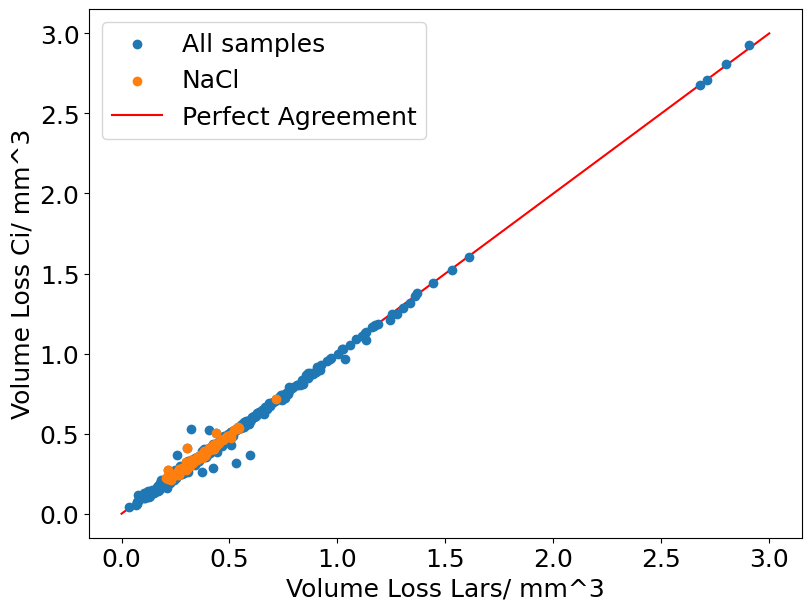

In [28]:
# Compare the volume loss determined by Ci and by me for all samples and the NaCl samples in particular
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
ax.scatter(inhibitor_df.target_volumeloss, inhibitor_df.volumeloss, label="All samples")
ax.scatter(nacl_df.target_volumeloss, nacl_df.volumeloss, label="NaCl")
ax.plot([0, 3], [0, 3], color='red', label='Perfect Agreement', zorder=0)
ax.set_xlabel("Volume Loss Lars/ mm^3")
ax.set_ylabel("Volume Loss Ci/ mm^3")
ax.legend()

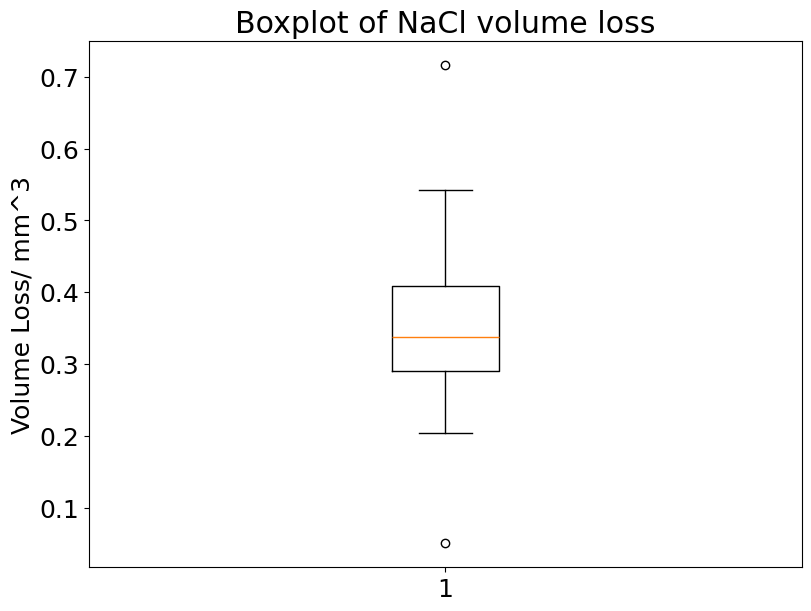

In [29]:
# Boxplot of NaCl sample volume loss
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
ax.boxplot(nacl_df.target_volumeloss)
ax.set_ylabel("Volume Loss/ mm^3")
ax.set_title("Boxplot of NaCl volume loss")
plt.show()

There are two outliers present in the NaCl samples. Let's have a look at them and compare to the average NaCl sample.

/tmp/ipykernel_2172432/73786395.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nacl_df["volumeloss_diff"] = (nacl_df.target_volumeloss - nacl_df.target_volumeloss.median()).abs()


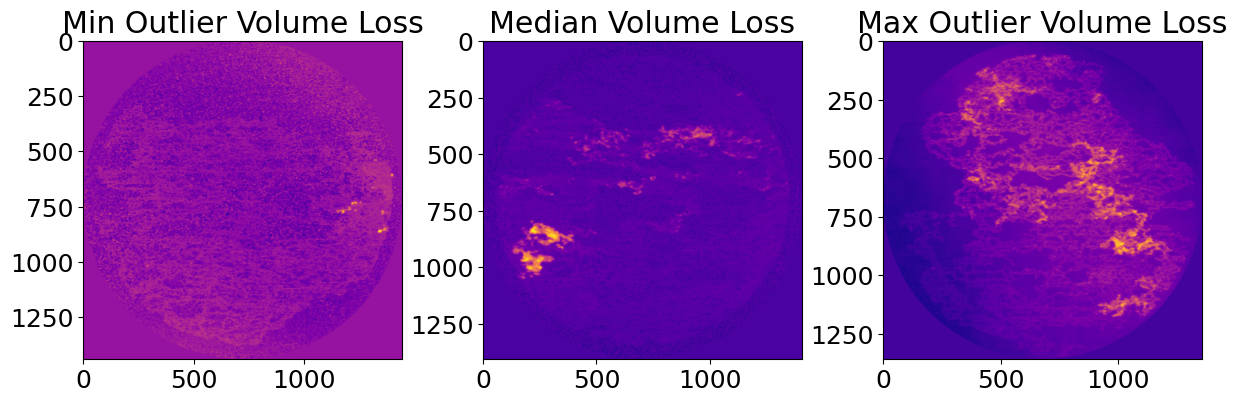

In [30]:
max_id = nacl_df[nacl_df.target_volumeloss == nacl_df.target_volumeloss.max()].id.values[0]
min_id = nacl_df[nacl_df.target_volumeloss == nacl_df.target_volumeloss.min()].id.values[0]

# Get id with volume loss closest to median
nacl_df["volumeloss_diff"] = (nacl_df.target_volumeloss - nacl_df.target_volumeloss.median()).abs()
avg_id = nacl_df[nacl_df.volumeloss_diff == nacl_df.volumeloss_diff.min()].id.values[0]

min_image = get_image(Path("../data/train/after/height"), Path("../data/train/mask"), f"{min_id}.npy")
max_image = get_image(Path("../data/train/after/height"), Path("../data/train/mask"), f"{max_id}.npy")
avg_image = get_image(Path("../data/train/after/height"), Path("../data/train/mask"), f"{avg_id}.npy")

# Show min and max and average image side by side
fig, ax = plt.subplots(1, 3, figsize=(12, 6), constrained_layout=True)
ax[0].imshow(min_image, cmap="plasma_r")
ax[0].set_title("Min Outlier Volume Loss")
ax[1].imshow(avg_image, cmap="plasma_r")
ax[1].set_title("Median Volume Loss")
ax[2].imshow(max_image, cmap="plasma_r")
ax[2].set_title("Max Outlier Volume Loss")
plt.show()

In [31]:
# Remove both outliers with their id and calculate the mean loss
nacl_df_no_outliers = nacl_df[~nacl_df.id.isin([min_id, max_id])]
mean_loss_no_outliers = nacl_df_no_outliers.target_volumeloss.mean()
NACL_VOLUMELOSS = mean_loss_no_outliers
NACL_VOLUMELOSS, nacl_df_no_outliers.target_volumeloss.std()

(np.float64(0.3500862295271533), np.float64(0.07866182918154555))

# Investigate MSE model

In [ ]:
def calc_ie_symmetric(loss):
    difference = NACL_VOLUMELOSS - loss

    if difference >= 0.0:
        return difference / NACL_VOLUMELOSS * 100
    else:
        return difference / loss * 100

def plot_ie_symmetric(ax, input_df):
    data_types = input_df.type.unique()

    for dtype in data_types:
        df = input_df[input_df.type == dtype]

        # Apply function to every entry in dataframe
        x = df.volumeloss_target.apply(calc_ie_symmetric)
        y = df.volumeloss_predict.apply(calc_ie_symmetric)
        ax.scatter(x, y, label=dtype)

    ax.plot(np.arange(-100, 110, 10), np.arange(-100, 110, 10), color="r")
    ax.set_xlabel("IE symmetric Target / %")
    ax.set_ylabel("IE symmetric Prediction / %")
    ax.set_xticks(np.arange(-100, 110, 20))
    ax.set_yticks(np.arange(-100, 110, 20))
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
    ax.legend()
    return ax

def plot_target_vs_prediction(ax, input_df):
    data_types = input_df.type.unique()

    for dtype in data_types:
        df = input_df[input_df.type == dtype]
        x = rel_target_loss(df)
        y = rel_pred_loss(df)
        ax.scatter(x, y, label=dtype)
    ax.plot(np.arange(0.0, 1.0, 0.01), np.arange(0.0, 1.0, 0.01), color="r")
    ax.set_xlabel("Volumeloss Target / a.u.")
    ax.set_ylabel("Volumeloss Prediction / a.u.")
    ax.grid()
    ax.legend()
    return ax

def plot_normalized_target_vs_prediction(ax, input_df):
    data_types = input_df.type.unique()

    for dtype in data_types:
        df = input_df[input_df.type == dtype]
        x = rel_target_loss(df)
        y = rel_pred_loss(df)/x
        ax.scatter(x, y, label=dtype)
    ax.set_xlabel("Volumeloss Target / a.u.")
    ax.set_ylabel("Volumeloss Prediction / Target")
    ax.grid()
    ax.legend()
    return ax

def save_side_by_side(model, data_type):

    save_path = get_save_path(model, data_type)
    ground_truth_path = get_target_path(data_type)
    mask_path = get_mask_path(data_type)

    numpy_save_path = save_path / "numpy"
    side_by_side_save_path = save_path / "side-by-side"
    side_by_side_save_path.mkdir(parents=True, exist_ok=True)

    files = os.listdir(numpy_save_path)

    for f in files:
        target = get_image(ground_truth_path, mask_path, f)
        prediction = get_image(numpy_save_path, mask_path, f)

        max_val = 0.0
        min_val = min(target.min(), prediction.min())

        fig = plt.figure(figsize=(10, 4))

        # 1 row, 3 columns: 2 for images, 1 thin column for colorbar
        gs = GridSpec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.1)

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        cax = fig.add_subplot(gs[0, 2])  # dedicated colorbar axis

        im1 = ax1.imshow(target, vmin=min_val, vmax=max_val, cmap="plasma_r")
        ax1.set_title("Ground Truth")
        im2 = ax2.imshow(prediction, vmin=min_val, vmax=max_val, cmap="plasma_r")
        ax2.set_title("Prediction")
        fig.colorbar(im2, cax=cax)
        plt.savefig(side_by_side_save_path / f.replace("npy", "png"), bbox_inches="tight")
        plt.close(fig)


## MSE loss model

In [ ]:
model = "model-d2rltbw6-best"

In [ ]:
save_side_by_side(model, "test")
save_side_by_side(model, "val")
save_side_by_side(model, "train")

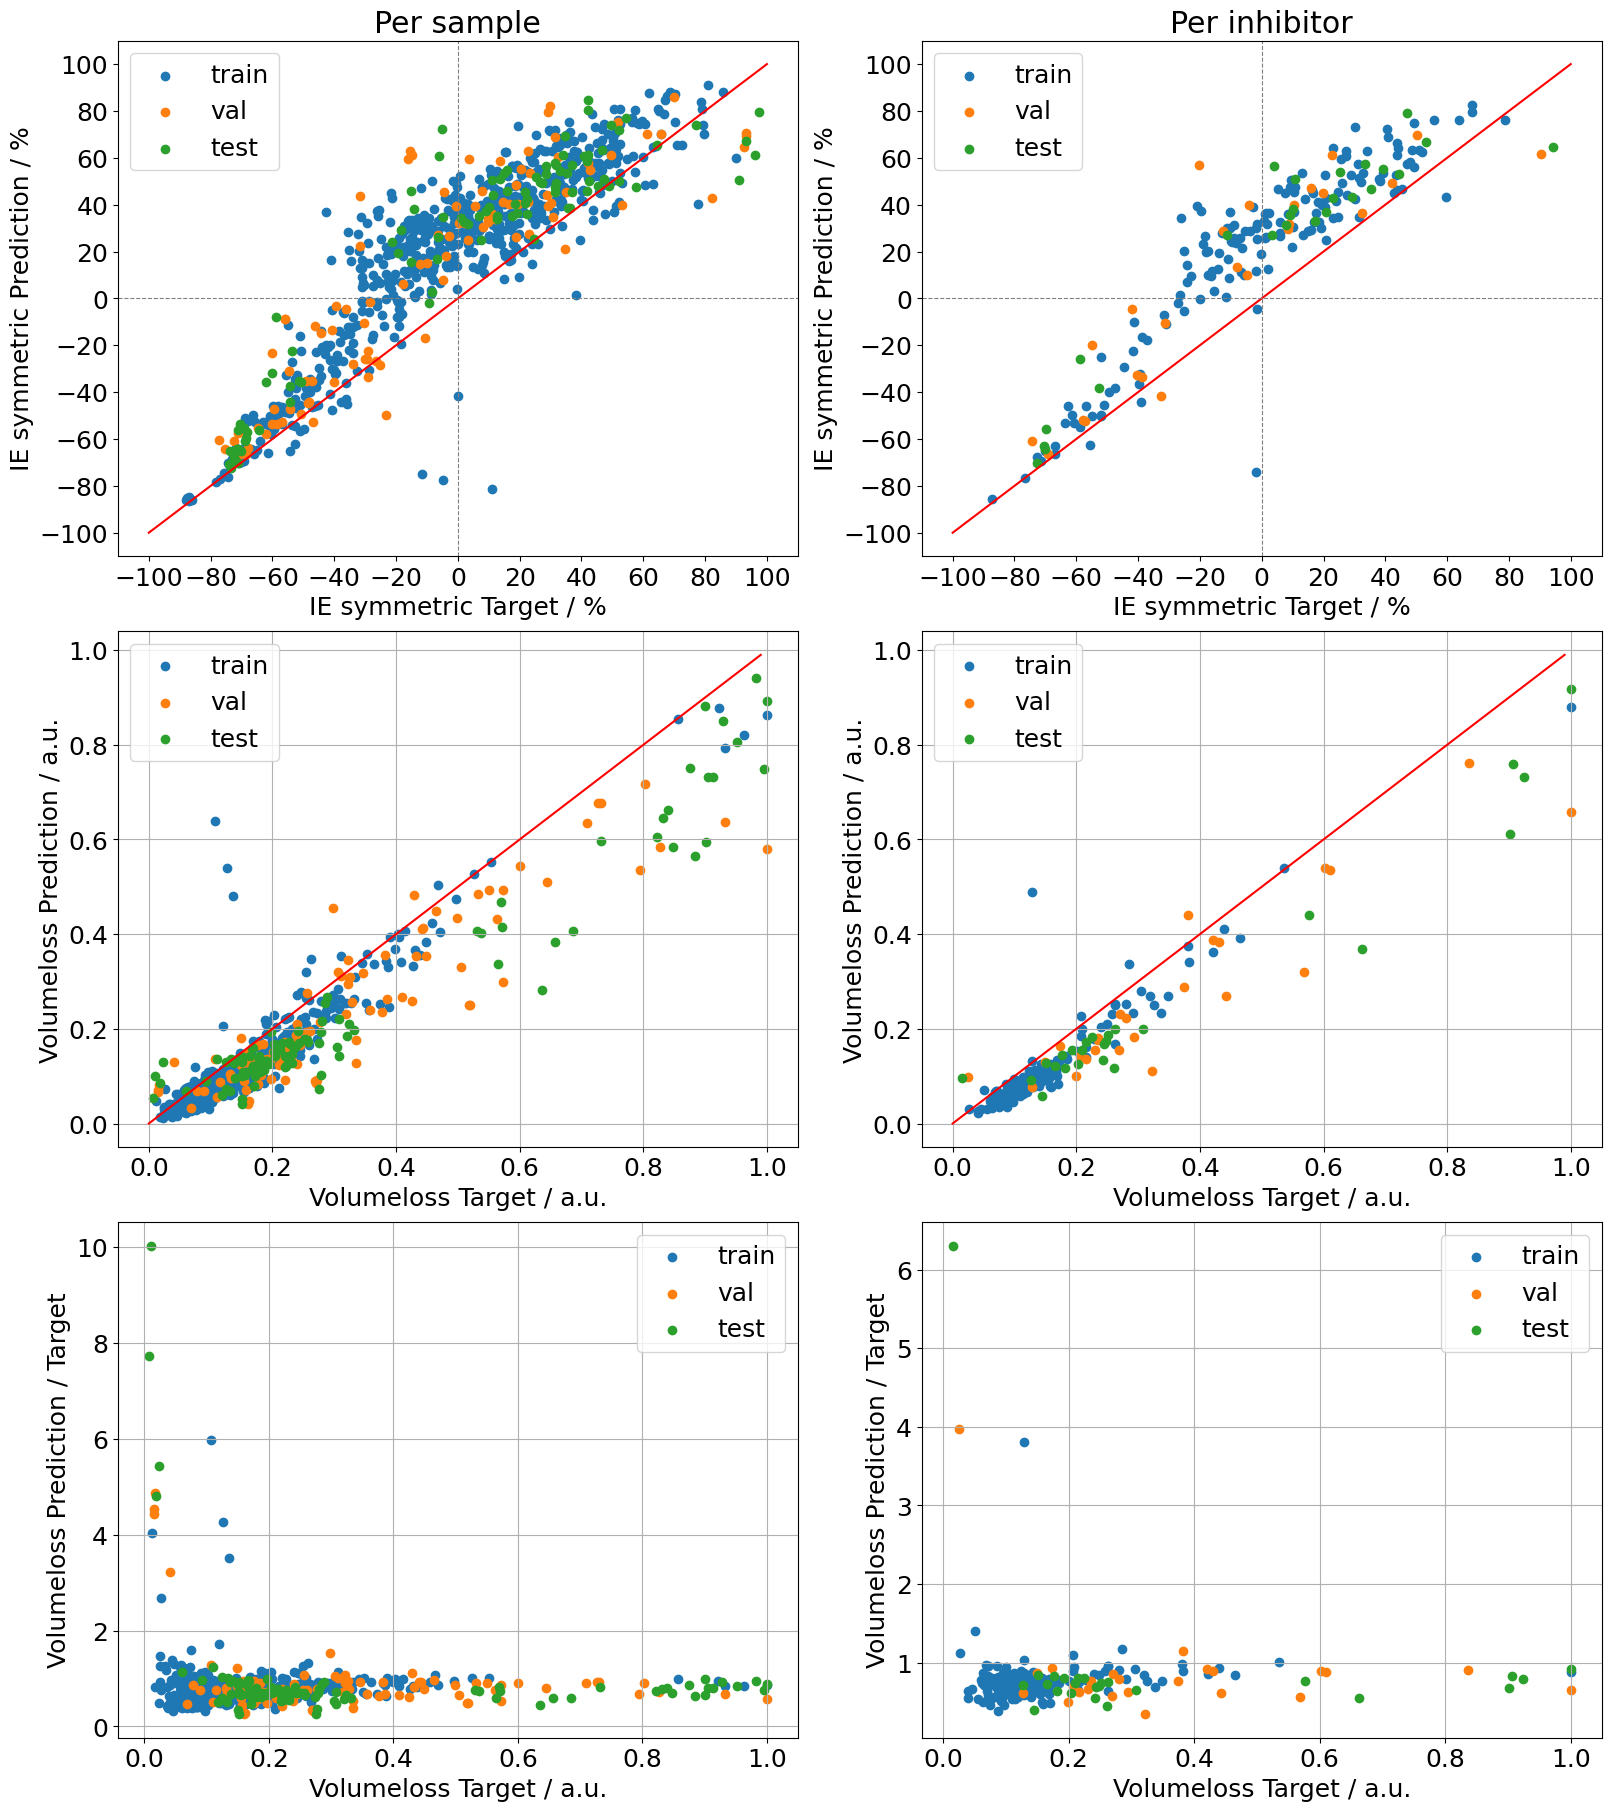

In [ ]:
data_types = ["train", "val", "test"]
results, inhibitor = create_result_df(model, data_types)

fig, ax = plt.subplots(3, 2, figsize=(16, 18), constrained_layout=True)

ax[0][0].set_title("Per sample")
ax[0][1].set_title("Per inhibitor")

plot_ie_symmetric(ax[0][0], results)
plot_ie_symmetric(ax[0][1], inhibitor)

plot_target_vs_prediction(ax[1][0], results)
plot_target_vs_prediction(ax[1][1], inhibitor)

plot_normalized_target_vs_prediction(ax[2][0], results)
plot_normalized_target_vs_prediction(ax[2][1], inhibitor)

plt.show()


## Determine systematic model bias

Systematic prediction bias of -25.59% for all samples
Systematic prediction bias of -26.09% for inhibitors


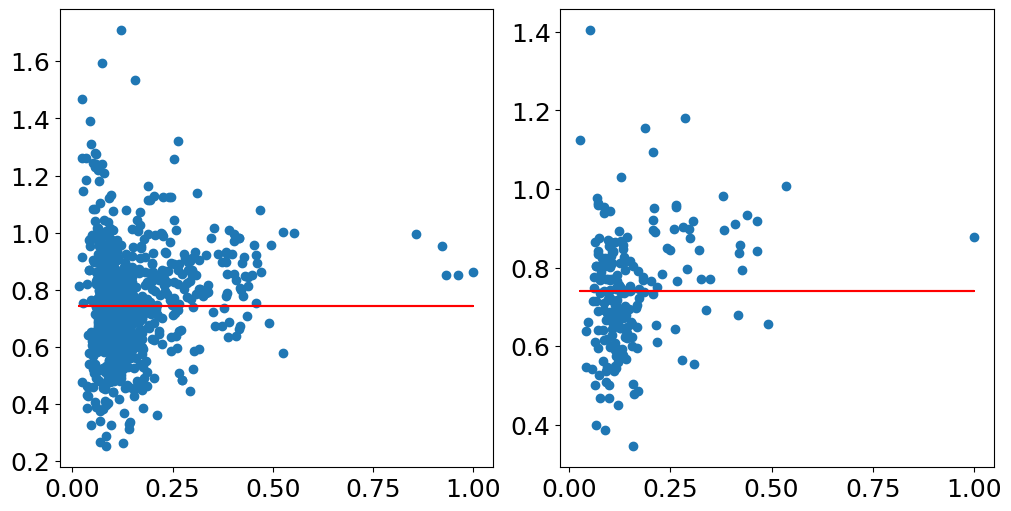

In [77]:
def line(t, b):
    return t * 0.0 + b

# Calculate relative prediction / target deviation
x_sample = rel_target_loss(results)
y_sample = rel_pred_loss(results) / x_sample

x_inhibitor = rel_target_loss(inhibitor)
y_inhibitor = rel_pred_loss(inhibitor) / x_inhibitor


# Remove outliers with y > 2.0
x_sample = x_sample[~(y_sample > 2.0)]
y_sample = y_sample[~(y_sample > 2.0)]

x_inhibitor = x_inhibitor[~(y_inhibitor > 2.0)]
y_inhibitor = y_inhibitor[~(y_inhibitor > 2.0)]

# Fit horizontal line to the data
popt_sample, pcov_sample = opt.curve_fit(line, x_sample, y_sample)
popt_inhibitor, pcov_inhibitor = opt.curve_fit(line, x_inhibitor, y_inhibitor)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

ax[0].scatter(x_sample, y_sample)
ax[0].plot(x_sample, line(x_sample, *popt_sample), 'r-')
print(f"Systematic prediction bias of {(popt_sample[0] - 1) * 100:.2f}% for all samples")

ax[1].scatter(x_inhibitor, y_inhibitor)
ax[1].plot(x_inhibitor, line(x_inhibitor, *popt_inhibitor), 'r-')
print(f"Systematic prediction bias of {(popt_inhibitor[0] - 1) * 100:.2f}% for inhibitors")

# Determine model score

In [81]:
def calc_model_deviation(df):
    return np.abs(df.volumeloss_target.apply(calc_ie_symmetric) - df.volumeloss_predict.apply(calc_ie_symmetric)).mean()

In [82]:
models = {"MSE": "model-d2rltbw6-best"}
data_types = ["train", "val", "test"]

for model_name in models.keys():
    model = models[model_name]
    results, inhibitor = create_result_df(model, data_types)
    sample_score = calc_model_deviation(results)
    inhibitor_score = calc_model_deviation(inhibitor)
    print(f"Model: {model_name}, Average Sample Deviation: {sample_score:.2f}%, Average Inhibitor Deviation: {inhibitor_score:.2f}%")


Model: MSE, Average Sample Deviation: 22.70%, Average Inhibitor Deviation: 22.51%
